# Consolidated XG & XGoT Rocessing
Uses models and defines how to develop features to apply them

## Imports

In [1]:
import sys
print(sys.executable)
import json
import time
import numpy as np
import pandas as pd
import joblib
from bs4 import BeautifulSoup

from pydantic import BaseModel
from typing import List, Optional

from selenium import webdriver
from tqdm import tqdm
from supabase import create_client, Client
import psycopg2
import re
import pandas as pd
import ast
from sklearn.model_selection import train_test_split

from tqdm import tqdm
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, f1_score
import pandas as pd


c:\Users\rogel\AppData\Local\Programs\Python\Python39\python.exe


## Methods

In [2]:
def extract_display_names(qualifiers_string):
    if pd.isna(qualifiers_string):
        return []
    try:
        qualifiers = ast.literal_eval(qualifiers_string)
        return [q['type']['displayName'] for q in qualifiers if 'type' in q and 'displayName' in q['type']]
    except Exception:
        return []

In [3]:
def calculate_shot_angle(x, y):
    goal_x, goal_y_top, goal_y_bottom = 100, 56, 44
    dx = goal_x - x
    dy_top = goal_y_top - y
    dy_bottom = goal_y_bottom - y
    
    # Angles from (x,y) to top and bottom posts
    angle_top = np.arctan2(dy_top, dx)
    angle_bottom = np.arctan2(dy_bottom, dx)
    
    # Angle between lines (always positive)
    angle = abs(angle_top - angle_bottom)
    
    # Convert to degrees
    return np.degrees(angle)

### Variables

In [4]:
qualifiers_of_interest = [
    'IntentionalAssist', 'IntentionalGoalAssist', 'Assisted', 'KeyPass', 'IndividualPlay',
    'RightFoot', 'LeftFoot', 'Head', 'OtherBodyPart', 'Volley', 'SetPiece', 'DirectFreekick', 'OneOnOne'
    ,'Penalty', 'DirectCorner'
]

## Getting the Data

In [5]:
conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password="admin",
    host="localhost",
    port=5432
)
cursor = conn.cursor()
cursor.execute("""
    SELECT * FROM match_events WHERE is_shot=TRUE;
""")
records = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
original_df = pd.DataFrame(records, columns=columns)

In [6]:
original_df.shape

(240237, 23)

## Data Processing

In [7]:
df=original_df[original_df['is_shot'] == True].copy()

# Step 2: Apply to your DataFrame
df['display_names'] = df['qualifiers'].apply(extract_display_names)

# Step 3: Flatten and get unique display names
all_display_names = set(name for sublist in df['display_names'] for name in sublist)

print(f"Unique display names: {sorted(all_display_names)}")

# Get list of display names per row
df['display_names'] = df['qualifiers'].apply(extract_display_names)

# Create binary columns for each qualifier
for qualifier in qualifiers_of_interest:
    df[f'qual_{qualifier}'] = df['display_names'].apply(lambda x: 1 if qualifier in x else 0)

# Optional: drop the intermediate column if you don’t need it
# df.drop(columns=['display_names'], inplace=True)

df['centered_y'] = 50 - abs(df['y'] - 50)
df['centered_goalmouth_y'] = 50 - abs(df['goal_mouth_y'] - 50)
df['shot_angle'] = df.apply(lambda row: calculate_shot_angle(row['x'], row['y']), axis=1)

# Distance to center (you already have this):
df['distance_to_goal_center'] = np.sqrt((100 - df['x'])**2 + (50 - df['y'])**2)

# Distance to left post
df['distance_to_left_post'] = np.sqrt((100 - df['x'])**2 + (44 - df['y'])**2)

# Distance to right post
df['distance_to_right_post'] = np.sqrt((100 - df['x'])**2 + (56 - df['y'])**2)

df = df[~((df['x'] < 50) & (df['is_goal'] == 1))]

Unique display names: ['Assisted', 'BigChance', 'BigChanceCreated', 'Blocked', 'BlockedX', 'BlockedY', 'BoxCentre', 'BoxLeft', 'BoxRight', 'DeepBoxLeft', 'DeepBoxRight', 'DirectCorner', 'DirectFreekick', 'FastBreak', 'FirstTouch', 'FromCorner', 'GoalMouthY', 'GoalMouthZ', 'Head', 'HighCentre', 'HighLeft', 'HighRight', 'IndividualPlay', 'IntentionalAssist', 'IntentionalGoalAssist', 'KeyPass', 'LeftFoot', 'LowCentre', 'LowLeft', 'LowRight', 'MissHigh', 'MissLeft', 'MissRight', 'OneOnOne', 'OppositeRelatedEvent', 'OtherBodyPart', 'OutOfBoxCentre', 'OutOfBoxDeepLeft', 'OutOfBoxDeepRight', 'OutOfBoxLeft', 'OutOfBoxRight', 'OwnGoal', 'Penalty', 'RegularPlay', 'RelatedEventId', 'RightFoot', 'SavedOffline', 'SetPiece', 'SixYardBlock', 'SmallBoxCentre', 'SmallBoxLeft', 'SmallBoxRight', 'StandingSave', 'ThirtyFivePlusCentre', 'ThirtyFivePlusLeft', 'ThirtyFivePlusRight', 'ThrowinSetPiece', 'Volley', 'Zone']


In [8]:
all_possible_features = [ #Miami Horror reference
    'x', 'y', 'id',
    'qual_IntentionalAssist', 'qual_IntentionalGoalAssist', 'qual_Assisted',
    'qual_KeyPass', 'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot',
    'qual_Head', 'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
       'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty', 'is_goal',
       'qual_DirectCorner', 'shot_angle', 'centered_y', 'distance_to_goal_center', 'distance_to_left_post', 'distance_to_right_post', 'goal_mouth_y', 'goal_mouth_z', 'centered_goalmouth_y'
]

target = 'is_goal'

In [9]:
df = df[all_possible_features]

In [10]:
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]  # Filter columns with any NaNs

df_clean = df.dropna(inplace=True)

## Modeling

### Reading the models

In [11]:
xg_model=joblib.load('../Models/xg/xg_model.pkl')
xgot_model=joblib.load('../Models/xgot/xgot_model.pkl')

### Defining features

In [12]:
xg_features = [
    'x', 'y',
    'qual_IntentionalAssist', 'qual_IntentionalGoalAssist', 'qual_Assisted',
    'qual_KeyPass', 'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot',
    'qual_Head', 'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
       'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty',
       'qual_DirectCorner', 'shot_angle', 'centered_y', 'distance_to_goal_center', 'distance_to_left_post', 'distance_to_right_post'
]

xgot_features = [
    'x', 'y',
    'qual_IntentionalAssist', 'qual_IntentionalGoalAssist', 'qual_Assisted',
    'qual_KeyPass', 'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot',
    'qual_Head', 'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
       'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty',
       'qual_DirectCorner', 'shot_angle', 'centered_y', 'distance_to_goal_center', 'distance_to_left_post', 'distance_to_right_post', 'goal_mouth_y', 'goal_mouth_z', 'centered_goalmouth_y'
]

target = 'is_goal'


### Filtering dataset

In [13]:
final_columns_xg = xg_features + [target]
final_columns_xgot = xgot_features + [target]

df_xgot = df[final_columns_xgot].copy()
df_xg = df[final_columns_xg].copy()

### Applying Models

In [14]:
xg_preds=xg_model.predict_proba(df_xg[xg_features])[:, 1]
xgot_preds=xgot_model.predict_proba(df_xgot[xgot_features])[:, 1]

## Returning the data to the original DF

In [15]:
df.loc[df_xg.index, 'xG_pred'] = xg_preds
df.loc[df_xgot.index, 'xGoT_pred'] = xgot_preds
df.loc[df['qual_Penalty'] == 1, 'xG_pred'] = 0.72

In [16]:
# Create a DataFrame with ids and predictions for both models
preds_df = pd.DataFrame({
    'id': df['id'],
    'xG_pred': df['xG_pred'],
    'xGoT_pred': df['xGoT_pred']
})

In [17]:
merged_df = original_df.merge(preds_df, on='id', how='left')

## Plotting the data

## Master xg and xgot method

In [18]:
def calculate_xg_xgot(df, xg_model, xgot_model):
    def extract_display_names(qualifiers_string):
        if pd.isna(qualifiers_string):
            return []
        try:
            qualifiers = ast.literal_eval(qualifiers_string)
            return [q['type']['displayName'] for q in qualifiers if 'type' in q and 'displayName' in q['type']]
        except Exception:
            return []
    
    def calculate_shot_angle(x, y):
        goal_x, goal_y_top, goal_y_bottom = 100, 56, 44
        dx = goal_x - x
        dy_top = goal_y_top - y
        dy_bottom = goal_y_bottom - y
        
        # Angles from (x,y) to top and bottom posts
        angle_top = np.arctan2(dy_top, dx)
        angle_bottom = np.arctan2(dy_bottom, dx)
        
        # Angle between lines (always positive)
        angle = abs(angle_top - angle_bottom)
        
        # Convert to degrees
        return np.degrees(angle)
    
    qualifiers_of_interest = [
        'IntentionalAssist', 'IntentionalGoalAssist', 'Assisted', 'KeyPass', 'IndividualPlay',
        'RightFoot', 'LeftFoot', 'Head', 'OtherBodyPart', 'Volley', 'SetPiece', 'DirectFreekick', 'OneOnOne'
        ,'Penalty', 'DirectCorner']
    
    df=original_df[original_df['is_shot'] == True].copy()

    # Step 2: Apply to your DataFrame
    df['display_names'] = df['qualifiers'].apply(extract_display_names)

    # Step 3: Flatten and get unique display names
    all_display_names = set(name for sublist in df['display_names'] for name in sublist)

    print(f"Unique display names: {sorted(all_display_names)}")

    # Get list of display names per row
    df['display_names'] = df['qualifiers'].apply(extract_display_names)

    # Create binary columns for each qualifier
    for qualifier in qualifiers_of_interest:
        df[f'qual_{qualifier}'] = df['display_names'].apply(lambda x: 1 if qualifier in x else 0)

    # Optional: drop the intermediate column if you don’t need it
    # df.drop(columns=['display_names'], inplace=True)

    df['centered_y'] = 50 - abs(df['y'] - 50)
    df['centered_goalmouth_y'] = 50 - abs(df['goal_mouth_y'] - 50)
    df['shot_angle'] = df.apply(lambda row: calculate_shot_angle(row['x'], row['y']), axis=1)

    # Distance to center (you already have this):
    df['distance_to_goal_center'] = np.sqrt((100 - df['x'])**2 + (50 - df['y'])**2)

    # Distance to left post
    df['distance_to_left_post'] = np.sqrt((100 - df['x'])**2 + (44 - df['y'])**2)

    # Distance to right post
    df['distance_to_right_post'] = np.sqrt((100 - df['x'])**2 + (56 - df['y'])**2)

    df = df[~((df['x'] < 50) & (df['is_goal'] == 1))]

    all_possible_features = [ #Miami Horror reference
        'x', 'y', 'id',
        'qual_IntentionalAssist', 'qual_IntentionalGoalAssist', 'qual_Assisted',
        'qual_KeyPass', 'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot',
        'qual_Head', 'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
        'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty', 'is_goal',
        'qual_DirectCorner', 'shot_angle', 'centered_y', 'distance_to_goal_center', 'distance_to_left_post', 'distance_to_right_post', 'goal_mouth_y', 'goal_mouth_z', 'centered_goalmouth_y']

    target = 'is_goal'
    df = df[all_possible_features]
    nan_counts = df.isna().sum()
    nan_counts = nan_counts[nan_counts > 0]  # Filter columns with any NaNs

    df_clean = df.dropna(inplace=True)

    xg_features = [
        'x', 'y',
        'qual_IntentionalAssist', 'qual_IntentionalGoalAssist', 'qual_Assisted',
        'qual_KeyPass', 'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot',
        'qual_Head', 'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
        'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty',
        'qual_DirectCorner', 'shot_angle', 'centered_y', 'distance_to_goal_center', 'distance_to_left_post', 'distance_to_right_post'
    ]

    xgot_features = [
        'x', 'y',
        'qual_IntentionalAssist', 'qual_IntentionalGoalAssist', 'qual_Assisted',
        'qual_KeyPass', 'qual_IndividualPlay', 'qual_RightFoot', 'qual_LeftFoot',
        'qual_Head', 'qual_OtherBodyPart', 'qual_Volley', 'qual_SetPiece',
        'qual_DirectFreekick', 'qual_OneOnOne', 'qual_Penalty',
        'qual_DirectCorner', 'shot_angle', 'centered_y', 'distance_to_goal_center', 'distance_to_left_post', 'distance_to_right_post', 'goal_mouth_y', 'goal_mouth_z', 'centered_goalmouth_y'
    ]

    target = 'is_goal'

    final_columns_xg = xg_features + [target]
    final_columns_xgot = xgot_features + [target]

    df_xgot = df[final_columns_xgot].copy()
    df_xg = df[final_columns_xg].copy()

    xg_preds=xg_model.predict_proba(df_xg[xg_features])[:, 1]
    xgot_preds=xgot_model.predict_proba(df_xgot[xgot_features])[:, 1]

    df.loc[df_xg.index, 'xG_pred'] = xg_preds
    df.loc[df_xgot.index, 'xGoT_pred'] = xgot_preds
    df.loc[df['qual_Penalty'] == 1, 'xG_pred'] = 0.72

    # Create a DataFrame with ids and predictions for both models
    preds_df = pd.DataFrame({
        'id': df['id'],
        'xG_pred': df['xG_pred'],
        'xGoT_pred': df['xGoT_pred']
    })

    merged_df = original_df.merge(preds_df, on='id', how='left')

    merged_df.loc[~merged_df['type_display_name'].isin(['Goal', 'SavedShot']), 'xGoT_pred'] = 0

    return merged_df

In [19]:
conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password="admin",
    host="localhost",
    port=5432
)
cursor = conn.cursor()
cursor.execute("""
    SELECT * FROM match_events WHERE is_shot=TRUE;
""")
records = cursor.fetchall()
columns = [desc[0] for desc in cursor.description]
original_df = pd.DataFrame(records, columns=columns)

In [20]:
xg_model=joblib.load('../Models/xg/xg_model.pkl')
xgot_model=joblib.load('../Models/xgot/xgot_model.pkl')

In [21]:
a=calculate_xg_xgot(original_df, xg_model, xgot_model)

Unique display names: ['Assisted', 'BigChance', 'BigChanceCreated', 'Blocked', 'BlockedX', 'BlockedY', 'BoxCentre', 'BoxLeft', 'BoxRight', 'DeepBoxLeft', 'DeepBoxRight', 'DirectCorner', 'DirectFreekick', 'FastBreak', 'FirstTouch', 'FromCorner', 'GoalMouthY', 'GoalMouthZ', 'Head', 'HighCentre', 'HighLeft', 'HighRight', 'IndividualPlay', 'IntentionalAssist', 'IntentionalGoalAssist', 'KeyPass', 'LeftFoot', 'LowCentre', 'LowLeft', 'LowRight', 'MissHigh', 'MissLeft', 'MissRight', 'OneOnOne', 'OppositeRelatedEvent', 'OtherBodyPart', 'OutOfBoxCentre', 'OutOfBoxDeepLeft', 'OutOfBoxDeepRight', 'OutOfBoxLeft', 'OutOfBoxRight', 'OwnGoal', 'Penalty', 'RegularPlay', 'RelatedEventId', 'RightFoot', 'SavedOffline', 'SetPiece', 'SixYardBlock', 'SmallBoxCentre', 'SmallBoxLeft', 'SmallBoxRight', 'StandingSave', 'ThirtyFivePlusCentre', 'ThirtyFivePlusLeft', 'ThirtyFivePlusRight', 'ThrowinSetPiece', 'Volley', 'Zone']


In [22]:
goal_sum = a['is_goal'].sum()
xg_sum = a['xG_pred'].sum()
xgot_sum = a['xGoT_pred'].sum()

print(f"Goals: {goal_sum}")
print(f"Expected Goals (xG): {xg_sum}")
print(f"Expected Goals on Target (xGoT): {xgot_sum}")

Goals: 27211
Expected Goals (xG): 25361.988478613453
Expected Goals on Target (xGoT): 26319.16754870772


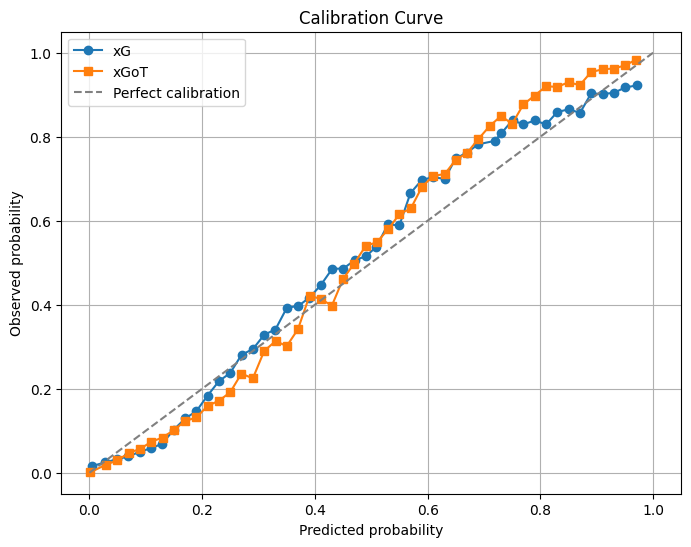

In [24]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Extract your arrays
y_true = a['is_goal']
xg_pred = a['xG_pred']
xgot_pred = a['xGoT_pred']

# Calibration curve for xG
prob_true_xg, prob_pred_xg = calibration_curve(y_true, xg_pred, n_bins=50, strategy='uniform')
# Calibration curve for xGoT
prob_true_xgot, prob_pred_xgot = calibration_curve(y_true, xgot_pred, n_bins=50, strategy='uniform')

plt.figure(figsize=(8, 6))
plt.plot(prob_pred_xg, prob_true_xg, marker='o', label='xG')
plt.plot(prob_pred_xgot, prob_true_xgot, marker='s', label='xGoT')

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')

plt.xlabel('Predicted probability')
plt.ylabel('Observed probability')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()
